In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import cv2
import os
import csv
import random
import matplotlib.pyplot as plt

from tqdm import tqdm
from glob import glob
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import *
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
import tensorflow.keras.backend as K

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from tensorflow.keras.layers.experimental import preprocessing
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

In [50]:
def plot_sample(X):
   
    nb_rows = 3
    nb_cols = 3
    fig, axs = plt.subplots(nb_rows, nb_cols, figsize=(6, 6))

    for i in range(0, nb_rows):
        for j in range(0, nb_cols):
            axs[i, j].xaxis.set_ticklabels([])
            axs[i, j].yaxis.set_ticklabels([])
            axs[i, j].imshow(X[random.randint(0, X.shape[0] - 1)])

def read_data(path_list, im_size=(224, 224)):
   
    X = []
    y = []
  
    tag2idx = {tag.split(os.path.sep)[-1]: i for i, tag in enumerate(path_list)}

    for path in path_list:
        for im_file in tqdm(glob(path + "*/*")):  
            try:              
                label = im_file.split(os.path.sep)[-2]
                im = cv2.imread(im_file, cv2.IMREAD_COLOR)               
                im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)               
                im = cv2.resize(im, im_size, interpolation=cv2.INTER_AREA)
                X.append(im)
                y.append(tag2idx[label]) 
            except Exception as e:
                
                print("Not a picture")

    X = np.array(X) 
    y = np.eye(len(np.unique(y)))[y].astype(np.uint8)

    return X, y

def get_callbacks(weights_file, patience, lr_factor):
    
    return [
    
        ModelCheckpoint(
            filepath=weights_file,
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
        ),
    
        EarlyStopping(monitor="val_loss", mode="min", patience=patience, verbose=1),
    ]


In [51]:
INPUT_SHAPE = (224, 224, 3)
IM_SIZE = (224, 224)
NUM_EPOCHS = 50
BATCH_SIZE = 4
#TRAIN_SPLIT = 0.99
TEST_SPLIT = 0.2
VAL_SPLIT = 0.2
RANDOM_STATE = 2021

PATH_LIST = [
    "/Users/HP/Downloads/NIR and REG Cut/Broadleaf/",
    "/Users/HP/Downloads/NIR and REG Cut/Crop/",
    "/Users/HP/Downloads/NIR and REG Cut/Sedge/",
   
]

In [76]:
i = 0
for path in PATH_LIST:
    PATH_LIST[i] = str(
        Path(Path.cwd()).parents[0].joinpath("").joinpath(path)
    )
    i += 1
X, y = read_data(PATH_LIST, IM_SIZE)

100%|██████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 48.50it/s]


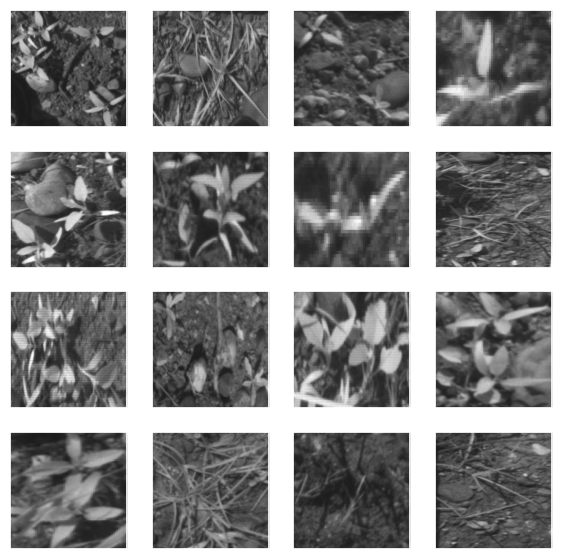

In [54]:
plot_sample(X)
sns.set_style()

In [56]:
img_augmentation = Sequential(
    [
        preprocessing.RandomRotation(factor=0.15),
        preprocessing.RandomTranslation(height_factor=0.1, width_factor=0.1),
        preprocessing.RandomFlip(),
        preprocessing.RandomZoom(0.1),
        preprocessing.RandomContrast(factor=0.1),
    ],
    name="img_augmentation",
)

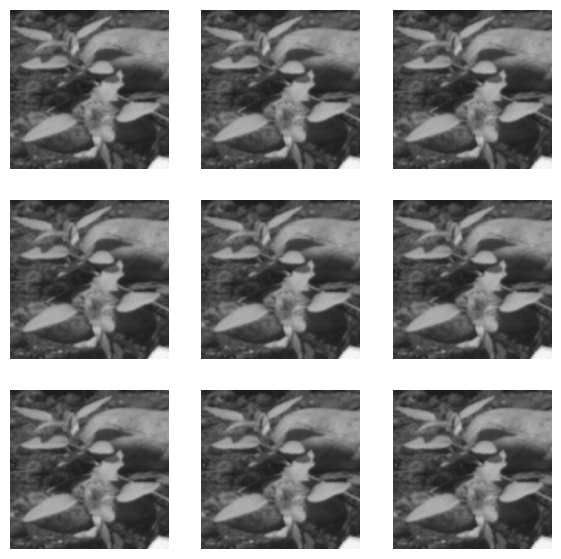

In [57]:
IMAGE_IX = 19
image = tf.expand_dims(X[IMAGE_IX], axis=0)
plt.figure(figsize=(7, 7))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    aug_img = img_augmentation(image)
    plt.imshow(aug_img[0].numpy().astype("uint8"))
    plt.axis("off")
plt.show()

In [58]:
def get_architecture(y, Model_Type, as_feature_extractor):
   
    inputs = layers.Input(shape=INPUT_SHAPE)
    input_aug = img_augmentation(inputs)
    input_norm = layers.Lambda(preprocess_input)(input_aug)

    if Model_Type == "MobileNetV2":
        feature_extractor = MobileNetV2(
            weights="imagenet", include_top=False, input_tensor=input_norm
        )
    elif Model_Type == "MobileNetV3Large":
        feature_extractor = MobileNetV3Large(
            weights="imagenet", include_top=False, input_tensor=input_norm
        )
  
    if as_feature_extractor:
        feature_extractor.trainable = False
    else:
        feature_extractor.trainable = True  
    features = layers.GlobalAveragePooling2D(name="pool")(
        feature_extractor.output
    ) 
    fully = layers.Dense(units=64, activation="relu")(features)     
    fully = layers.Dropout(0.3)(fully) 
    out = layers.Dense(units=y.shape[1], activation="softmax")(fully)
    model = Model(inputs, out)
    
    base_learning_rate = 1e-2
    model.compile(
        loss="categorical_crossentropy",
        optimizer=tf.keras.optimizers.SGD(lr=base_learning_rate),
        metrics=["accuracy"],
    )
    return model

In [77]:
model = get_architecture(y, Model_Type="MobileNetV3Large", as_feature_extractor=False)

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=TEST_SPLIT, 
    shuffle=True, 
    stratify=y, 
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=VAL_SPLIT,
    shuffle=True,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

In [36]:
#REG
history_MobileNetV3Large_ft = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
#model.load_weights(WEIGHTS_FILE)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final MobileNetV3Large (Fine-Tuning) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/50
50/50 [==============================] - 50s 743ms/step - loss: 0.9022 - accuracy: 0.5960 - val_loss: 0.7717 - val_accuracy: 0.6800
Epoch 2/50
50/50 [==============================] - 36s 714ms/step - loss: 0.5520 - accuracy: 0.7980 - val_loss: 0.5449 - val_accuracy: 0.8000
Epoch 3/50
50/50 [==============================] - 36s 729ms/step - loss: 0.5386 - accuracy: 0.7879 - val_loss: 0.4155 - val_accuracy: 0.8200
Epoch 4/50
50/50 [==============================] - 38s 755ms/step - loss: 0.3805 - accuracy: 0.8788 - val_loss: 0.2822 - val_accuracy: 0.9400
Epoch 5/50
50/50 [==============================] - 35s 707ms/step - loss: 0.3804 - accuracy: 0.8535 - val_loss: 0.1948 - val_accuracy: 0.9400
Epoch 6/50
50/50 [==============================] - 36s 715ms/step - loss: 0.3773 - accuracy: 0.8586 - val_loss: 0.1849 - val_accuracy: 0.9400
Epoch 7/50
50/50 [==============================] - 38s 757ms/step - loss: 0.3577 - accuracy: 0.8737 - val_loss: 0.1645 - val_accuracy: 0.9600

50/50 [==============================] - 42s 840ms/step - loss: 0.0518 - accuracy: 0.9899 - val_loss: 0.1146 - val_accuracy: 0.9600
Epoch 43/50
50/50 [==============================] - 39s 775ms/step - loss: 0.0476 - accuracy: 0.9848 - val_loss: 0.1415 - val_accuracy: 0.9600
Epoch 44/50
50/50 [==============================] - 38s 750ms/step - loss: 0.0595 - accuracy: 0.9848 - val_loss: 0.1154 - val_accuracy: 0.9600
Epoch 45/50
50/50 [==============================] - 38s 753ms/step - loss: 0.0184 - accuracy: 1.0000 - val_loss: 0.1195 - val_accuracy: 0.9400
Epoch 46/50
50/50 [==============================] - 37s 750ms/step - loss: 0.0663 - accuracy: 0.9798 - val_loss: 0.1113 - val_accuracy: 0.9800
Epoch 47/50
50/50 [==============================] - 40s 804ms/step - loss: 0.0280 - accuracy: 0.9899 - val_loss: 0.1280 - val_accuracy: 0.9600
Epoch 48/50
50/50 [==============================] - 44s 889ms/step - loss: 0.0589 - accuracy: 0.9848 - val_loss: 0.1275 - val_accuracy: 0.9400
Epoc

In [63]:
#NIR and REG
history_MobileNetV3Large_ft = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)
#model.load_weights(WEIGHTS_FILE)
final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final MobileNetV3Large (Fine-Tuning) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/50
96/96 [==============================] - 95s 831ms/step - loss: 0.7175 - accuracy: 0.7005 - val_loss: 0.7527 - val_accuracy: 0.7188
Epoch 2/50
96/96 [==============================] - 69s 719ms/step - loss: 0.4542 - accuracy: 0.8281 - val_loss: 0.6457 - val_accuracy: 0.7396
Epoch 3/50
96/96 [==============================] - 72s 754ms/step - loss: 0.3469 - accuracy: 0.8646 - val_loss: 0.7228 - val_accuracy: 0.7500
Epoch 4/50
96/96 [==============================] - 84s 876ms/step - loss: 0.3157 - accuracy: 0.8932 - val_loss: 0.4714 - val_accuracy: 0.8021
Epoch 5/50
96/96 [==============================] - 77s 800ms/step - loss: 0.2938 - accuracy: 0.8906 - val_loss: 0.4281 - val_accuracy: 0.8229
Epoch 6/50
96/96 [==============================] - 77s 807ms/step - loss: 0.2305 - accuracy: 0.9271 - val_loss: 0.4767 - val_accuracy: 0.8021
Epoch 7/50
96/96 [==============================] - 81s 845ms/step - loss: 0.2158 - accuracy: 0.9271 - val_loss: 0.5553 - val_accuracy: 0.8125

96/96 [==============================] - 90s 935ms/step - loss: 0.0811 - accuracy: 0.9635 - val_loss: 0.1322 - val_accuracy: 0.9688
Epoch 43/50
96/96 [==============================] - 93s 969ms/step - loss: 0.0156 - accuracy: 0.9974 - val_loss: 0.1979 - val_accuracy: 0.9375
Epoch 44/50
96/96 [==============================] - 93s 968ms/step - loss: 0.0206 - accuracy: 0.9948 - val_loss: 0.2030 - val_accuracy: 0.9375
Epoch 45/50
96/96 [==============================] - 93s 975ms/step - loss: 0.0496 - accuracy: 0.9792 - val_loss: 0.3580 - val_accuracy: 0.8854
Epoch 46/50
96/96 [==============================] - 92s 958ms/step - loss: 0.0419 - accuracy: 0.9896 - val_loss: 0.2960 - val_accuracy: 0.9167
Epoch 47/50
96/96 [==============================] - 79s 819ms/step - loss: 0.0137 - accuracy: 0.9974 - val_loss: 0.2517 - val_accuracy: 0.9479
Epoch 48/50
96/96 [==============================] - 76s 794ms/step - loss: 0.0209 - accuracy: 0.9896 - val_loss: 0.2010 - val_accuracy: 0.9583
Epoc

In [80]:
history_MobileNetV3Large_ft = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)

final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final MobileNetV3Large (Fine-Tuning) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/50
47/47 [==============================] - 56s 938ms/step - loss: 0.8754 - accuracy: 0.6216 - val_loss: 0.7522 - val_accuracy: 0.6596
Epoch 2/50
47/47 [==============================] - 38s 803ms/step - loss: 0.6691 - accuracy: 0.7405 - val_loss: 0.4734 - val_accuracy: 0.7660
Epoch 3/50
47/47 [==============================] - 47s 992ms/step - loss: 0.5911 - accuracy: 0.7784 - val_loss: 0.3761 - val_accuracy: 0.8936
Epoch 4/50
47/47 [==============================] - 36s 772ms/step - loss: 0.4874 - accuracy: 0.8486 - val_loss: 0.3402 - val_accuracy: 0.8511
Epoch 5/50
47/47 [==============================] - 36s 758ms/step - loss: 0.3390 - accuracy: 0.8649 - val_loss: 0.2862 - val_accuracy: 0.8511
Epoch 6/50
47/47 [==============================] - 37s 794ms/step - loss: 0.2830 - accuracy: 0.8973 - val_loss: 0.2128 - val_accuracy: 0.9787
Epoch 7/50
47/47 [==============================] - 37s 783ms/step - loss: 0.3507 - accuracy: 0.8595 - val_loss: 0.4948 - val_accuracy: 0.8723

47/47 [==============================] - 42s 883ms/step - loss: 0.0822 - accuracy: 0.9568 - val_loss: 0.3610 - val_accuracy: 0.9149
Epoch 43/50
47/47 [==============================] - 43s 908ms/step - loss: 0.0472 - accuracy: 0.9946 - val_loss: 0.5262 - val_accuracy: 0.8936
Epoch 44/50
47/47 [==============================] - 40s 844ms/step - loss: 0.0895 - accuracy: 0.9730 - val_loss: 0.5358 - val_accuracy: 0.8936
Epoch 45/50
47/47 [==============================] - 43s 908ms/step - loss: 0.0461 - accuracy: 0.9892 - val_loss: 0.5333 - val_accuracy: 0.8723
Epoch 46/50
47/47 [==============================] - 43s 914ms/step - loss: 0.0409 - accuracy: 0.9838 - val_loss: 0.5285 - val_accuracy: 0.8511
Epoch 47/50
47/47 [==============================] - 43s 906ms/step - loss: 0.1469 - accuracy: 0.9676 - val_loss: 0.4437 - val_accuracy: 0.8936
Epoch 48/50
47/47 [==============================] - 43s 912ms/step - loss: 0.0767 - accuracy: 0.9784 - val_loss: 0.6020 - val_accuracy: 0.8936
Epoc

In [67]:
#NIR
history_MobileNetV3Large_ft = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)

final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final MobileNetV3Large (Fine-Tuning) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/50
47/47 [==============================] - 51s 784ms/step - loss: 0.7968 - accuracy: 0.6703 - val_loss: 0.9045 - val_accuracy: 0.6809
Epoch 2/50
47/47 [==============================] - 34s 719ms/step - loss: 0.5769 - accuracy: 0.7838 - val_loss: 0.6358 - val_accuracy: 0.7234
Epoch 3/50
47/47 [==============================] - 37s 799ms/step - loss: 0.4101 - accuracy: 0.8378 - val_loss: 0.8593 - val_accuracy: 0.7447
Epoch 4/50
47/47 [==============================] - 42s 908ms/step - loss: 0.3923 - accuracy: 0.8541 - val_loss: 0.5356 - val_accuracy: 0.8298
Epoch 5/50
47/47 [==============================] - 37s 790ms/step - loss: 0.4008 - accuracy: 0.8486 - val_loss: 0.8364 - val_accuracy: 0.7447
Epoch 6/50
47/47 [==============================] - 35s 744ms/step - loss: 0.2754 - accuracy: 0.8919 - val_loss: 0.7096 - val_accuracy: 0.7872
Epoch 7/50
47/47 [==============================] - 34s 723ms/step - loss: 0.3327 - accuracy: 0.8973 - val_loss: 0.9474 - val_accuracy: 0.7660

In [22]:

history_MobileNetV3Large_ft = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(WEIGHTS_FILE, NUM_EPOCHS // 2, 0.25),
)

final_accuracy = model.evaluate(X_test, y_test, batch_size=1, verbose=0)[1]
print("*" * 72)
print(f"Final MobileNetV3Large (Fine-Tuning) Accuracy: {final_accuracy}")
print("*" * 72)

Epoch 1/50
47/47 [==============================] - 51s 731ms/step - loss: 0.8990 - accuracy: 0.6378 - val_loss: 0.7545 - val_accuracy: 0.7234
Epoch 2/50
47/47 [==============================] - 34s 730ms/step - loss: 0.6651 - accuracy: 0.7297 - val_loss: 0.6497 - val_accuracy: 0.6809
Epoch 3/50
47/47 [==============================] - 35s 753ms/step - loss: 0.4796 - accuracy: 0.7946 - val_loss: 0.4731 - val_accuracy: 0.7660
Epoch 4/50
47/47 [==============================] - 34s 727ms/step - loss: 0.4236 - accuracy: 0.8432 - val_loss: 0.3221 - val_accuracy: 0.8723
Epoch 5/50
47/47 [==============================] - 34s 720ms/step - loss: 0.4132 - accuracy: 0.8649 - val_loss: 0.2804 - val_accuracy: 0.8723
Epoch 6/50
47/47 [==============================] - 35s 738ms/step - loss: 0.3639 - accuracy: 0.8703 - val_loss: 0.2072 - val_accuracy: 0.9149
Epoch 7/50
47/47 [==============================] - 36s 778ms/step - loss: 0.2807 - accuracy: 0.9189 - val_loss: 0.2339 - val_accuracy: 0.8723